# Bài tập: Tính và cập nhật trọng số bằng Gradient Descent

Mục tiêu:
- Tính dự đoán từ trọng số.
- Tính sai số và hàm mất mát.
- Tính gradient theo trọng số.
- Cập nhật trọng số theo công thức Gradient Descent.

Ràng buộc: chỉ dùng `numpy` cho phần code và `matplotlib` cho phần vẽ đồ thị.

In [1]:
import numpy as np

# Dữ liệu linear regression
x_linear = np.array([-3.0, -2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4, 3.0])
y_linear = np.array([-8.7, -6.6, -5.4, -4.0, -2.4, -1.0, 0.0, 1.6, 3.0, 4.7, 6.2])

# Tham số khởi tạo đã cho
w_linear = 0.3
b_linear = 0.0
learning_rate_linear = 0.03
epochs_linear = 120

print("x_linear =", x_linear)
print("y_linear =", y_linear)
print("w_linear ban đầu =", w_linear)
print("b_linear ban đầu =", b_linear)
print("learning_rate_linear =", learning_rate_linear)

x_linear = [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
y_linear = [-8.7 -6.6 -5.4 -4.  -2.4 -1.   0.   1.6  3.   4.7  6.2]
w_linear ban đầu = 0.3
b_linear ban đầu = 0.0
learning_rate_linear = 0.03


In [2]:
def predict_linear(x, w, b):
    return w * x + b
def mse_loss(y, yp):
    return np.mean((yp - y) ** 2)
def compute_linear_gradients(x, y, yp):
    e = yp - y
    return 2 * np.mean(x * e), 2 * np.mean(e)

In [3]:
loss_history_linear = []
for epoch in range(epochs_linear):
    yp = predict_linear(x_linear, w_linear, b_linear)
    loss = mse_loss(y_linear, yp)
    loss_history_linear.append(loss)
    gw, gb = compute_linear_gradients(x_linear, y_linear, yp)
    w_linear -= learning_rate_linear * gw
    b_linear -= learning_rate_linear * gb
    if epoch % 20 == 0 or epoch == epochs_linear - 1:
        print(f"epoch {epoch:3d} | loss = {loss:8.4f} | w = {w_linear:6.3f} | b = {b_linear:6.3f}")

epoch   0 | loss =  17.2513 | w =  0.754 | b = -0.069
epoch  20 | loss =   0.1517 | w =  2.389 | b = -0.833
epoch  40 | loss =   0.0496 | w =  2.401 | b = -1.055
epoch  60 | loss =   0.0411 | w =  2.402 | b = -1.119
epoch  80 | loss =   0.0404 | w =  2.402 | b = -1.138
epoch 100 | loss =   0.0403 | w =  2.402 | b = -1.143
epoch 119 | loss =   0.0403 | w =  2.402 | b = -1.145


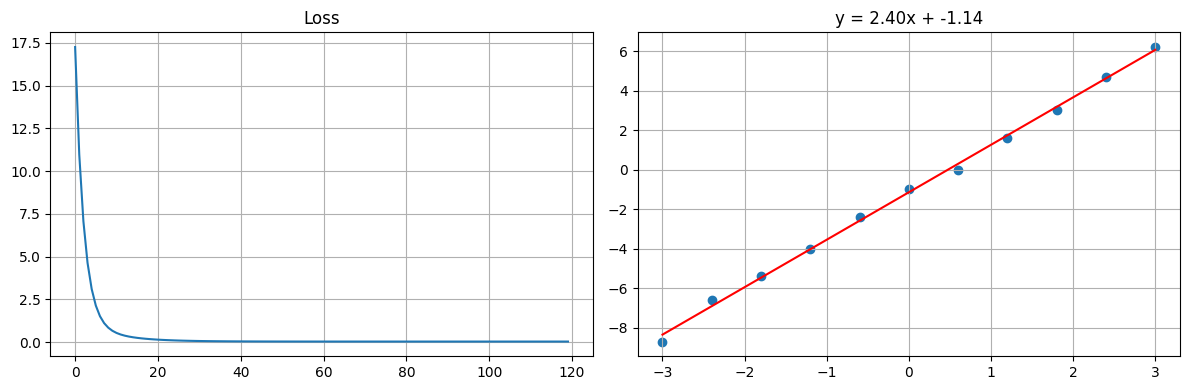

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history_linear)
plt.title('Loss')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(x_linear, y_linear)
plt.plot(x_linear, predict_linear(x_linear, w_linear, b_linear), 'r-')
plt.title(f'y = {w_linear:.2f}x + {b_linear:.2f}')
plt.grid()
plt.tight_layout()
plt.show()

In [5]:
# Dữ liệu logistic regression
x_logistic = np.array([-3.2, -2.7, -2.1, -1.5, -0.9, -0.4, 0.1, 0.5, 0.9, 1.4, 2.0, 2.6, 3.1])
y_logistic = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Tham số khởi tạo
w_logistic = -0.2
b_logistic = 0.1
learning_rate_logistic = 0.15
epochs_logistic = 150

print("x_logistic =", x_logistic)
print("y_logistic =", y_logistic)
print("w_logistic ban đầu =", w_logistic)
print("b_logistic ban đầu =", b_logistic)
print("learning_rate_logistic =", learning_rate_logistic)

x_logistic = [-3.2 -2.7 -2.1 -1.5 -0.9 -0.4  0.1  0.5  0.9  1.4  2.   2.6  3.1]
y_logistic = [0 0 0 0 0 1 0 1 1 1 1 1 1]
w_logistic ban đầu = -0.2
b_logistic ban đầu = 0.1
learning_rate_logistic = 0.15


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def predict_proba_logistic(x, w, b):
    return sigmoid(w * x + b)
def binary_cross_entropy(y, yp):
    yp = np.clip(yp, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(yp) + (1 - y) * np.log(1 - yp))
def compute_logistic_gradients(x, y, yp):
    return np.mean(x * (yp - y)), np.mean(yp - y)

In [7]:
loss_history_logistic = []
for epoch in range(epochs_logistic):
    yp = predict_proba_logistic(x_logistic, w_logistic, b_logistic)
    loss = binary_cross_entropy(y_logistic, yp)
    loss_history_logistic.append(loss)
    gw, gb = compute_logistic_gradients(x_logistic, y_logistic, yp)
    w_logistic -= learning_rate_logistic * gw
    b_logistic -= learning_rate_logistic * gb
    if epoch % 25 == 0 or epoch == epochs_logistic - 1:
        print(f"epoch {epoch:3d} | loss = {loss:8.4f} | w = {w_logistic:6.3f} | b = {b_logistic:6.3f}")
final_proba_logistic = predict_proba_logistic(x_logistic, w_logistic, b_logistic)

epoch   0 | loss =   0.8660 | w = -0.055 | b =  0.102
epoch  25 | loss =   0.2670 | w =  1.112 | b =  0.161
epoch  50 | loss =   0.2300 | w =  1.467 | b =  0.214
epoch  75 | loss =   0.2167 | w =  1.683 | b =  0.257
epoch 100 | loss =   0.2100 | w =  1.836 | b =  0.291
epoch 125 | loss =   0.2060 | w =  1.953 | b =  0.319
epoch 149 | loss =   0.2036 | w =  2.043 | b =  0.341


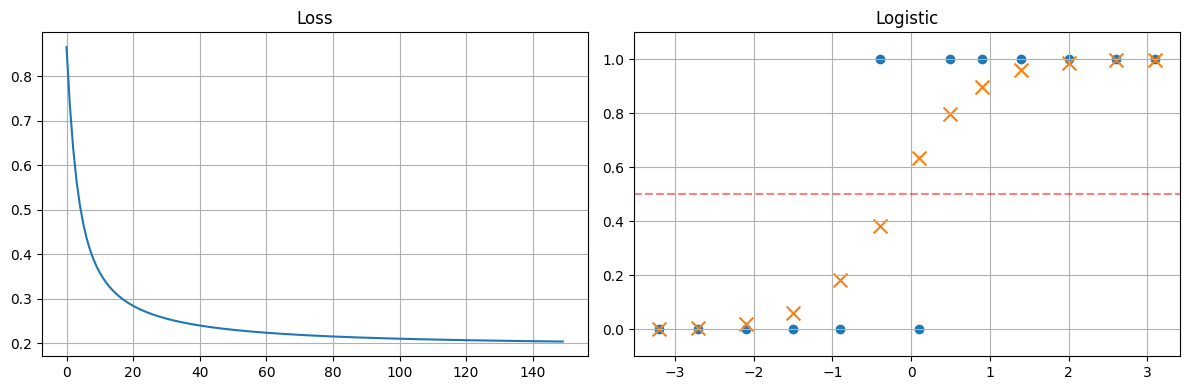

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history_logistic)
plt.title('Loss')
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(x_logistic, y_logistic)
plt.scatter(x_logistic, final_proba_logistic, marker='x', s=100)
plt.axhline(0.5, color='r', linestyle='--', alpha=0.5)
plt.title('Logistic')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.tight_layout()
plt.show()